# IST 652 Term Project -- Group 2
## Marcus Johnson
## Start Date: 10/22/25
### Horse_racing & Betting Data

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
# Get working directory to import data correctly

os.getcwd() # '/home/jovyan/library/Term Project'
!ls '/home/jovyan/library/Term Project/Horses/French Trotters'

French_horse_statistics_04.json  French_horse_statistics_14.json
French_horse_statistics_05.json  French_horse_statistics_15.json
French_horse_statistics_06.json  French_horse_statistics_16.json
French_horse_statistics_07.json  French_horse_statistics_17.json
French_horse_statistics_08.json  French_horse_statistics_18.json
French_horse_statistics_09.json  French_horse_statistics_19.json
French_horse_statistics_10.json  French_horse_statistics_20.json
French_horse_statistics_11.json  French_horse_statistics_21.json
French_horse_statistics_12.json  French_horse_statistics_22.json
French_horse_statistics_13.json  French_horse_statistics_23.json


# Horse data read, clean, and join

## French Trotter read, clean, join

In [2]:
file_yr = 4
ft_data = pd.DataFrame()
while file_yr < 24:
    ft_path = f"/home/jovyan/library/Term Project/Horses/French Trotters/French_horse_statistics_{file_yr:02}.json"
    with open(ft_path, "r") as file:
        ft_append = pd.DataFrame(json.load(file))

# Add year column and breed column to combine with rank for unique id
    ft_append["year"] = f"{file_yr:02d}"
    ft_append["breed"] = "French_Trotter"
    ft_append["unique_id"] = ft_append["rank"].astype(str) + "_" + ft_append["year"] + "_" + ft_append["breed"]

# Concatenate ft_append to ft_data 
    ft_data = pd.concat([ft_data, ft_append], ignore_index = True)
    file_yr += 1

ft_data = ft_data.rename(columns=
                         {"placePct_1": "#_category_1_race_entries",
                          "placePct_2": "#_category_2_race_entries",
                          "placePct_3": "#_category_3_race_entries",
                          "placePct_4": "#_category_4_race_entries",
                          "placePct_5": "#_category_5_race_entries",
                          "placePct_unplaced": "listed_race_entries",
                          "earnings":"earnings_(USD)"}
                        )
ft_data["earnings_(USD)"] = ft_data["earnings_(USD)"].astype(str).str.replace(r"[^\d.]", "", regex=True).str.strip().str.replace("Pln", "", regex=False).str.replace("PLN", "", regex=False).str.replace("pln", "", regex=False).str.replace(",", "", regex=False).str.replace(" ","", regex=False).str.strip().astype(int) # had chatGPT write the regex for me
ft_data["earnings_(USD)"] = (ft_data["earnings_(USD)"]  * .27379473).round(2)
if 'suma' in ft_data['name'].unique() or 'sum' in ft_data['name'].unique(): # Drop sum lines
    ft_data = ft_data.drop(ft_data[ft_data['name'].isin(['suma', 'sum'])].index)
ft_data["#_category_1_race_entries"] = ft_data["#_category_1_race_entries"].str[0]
ft_data["#_category_2_race_entries"] = ft_data["#_category_2_race_entries"].str[0]
ft_data["#_category_3_race_entries"] = ft_data["#_category_3_race_entries"].str[0]
ft_data["#_category_4_race_entries"] = ft_data["#_category_4_race_entries"].str[0]
ft_data["#_category_5_race_entries"] = ft_data["#_category_5_race_entries"].str[0]
ft_data["listed_race_entries"] = ft_data["listed_race_entries"].str[0]
french_trotters = ft_data.set_index("unique_id")
ft_data

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed,unique_id
0,1,The Plaisir Bark,2,0,0,0,0,0,2,3863.52,04,French_Trotter,1_04_French_Trotter
1,2,Lucky De Genetine,0,2,0,0,0,0,2,1545.30,04,French_Trotter,2_04_French_Trotter
2,3,Lise De Donzy,0,0,1,0,0,1,2,386.32,04,French_Trotter,3_04_French_Trotter
3,4,Lucky Star,0,0,1,0,0,1,2,386.32,04,French_Trotter,4_04_French_Trotter
4,5,Maya D'ortige,0,0,0,1,0,0,1,193.30,04,French_Trotter,5_04_French_Trotter
...,...,...,...,...,...,...,...,...,...,...,...,...,...
860,34,Jadysse De Cym,0,0,0,0,0,2,2,0.00,23,French_Trotter,34_23_French_Trotter
861,35,Hadol De Brion,0,0,0,0,0,2,2,0.00,23,French_Trotter,35_23_French_Trotter
862,36,The Idea Miron,0,0,0,0,0,2,2,0.00,23,French_Trotter,36_23_French_Trotter
863,37,Johnny Rep,0,0,0,0,0,1,1,0.00,23,French_Trotter,37_23_French_Trotter


In [3]:
french_trotters # French trotter horses with {rank}_{year}_{breed} as index to avoid duplicate horse entries

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed
unique_id,,,,,,,,,,,,
1_04_French_Trotter,1,The Plaisir Bark,2,0,0,0,0,0,2,3863.52,04,French_Trotter
2_04_French_Trotter,2,Lucky De Genetine,0,2,0,0,0,0,2,1545.30,04,French_Trotter
3_04_French_Trotter,3,Lise De Donzy,0,0,1,0,0,1,2,386.32,04,French_Trotter
4_04_French_Trotter,4,Lucky Star,0,0,1,0,0,1,2,386.32,04,French_Trotter
5_04_French_Trotter,5,Maya D'ortige,0,0,0,1,0,0,1,193.30,04,French_Trotter
...,...,...,...,...,...,...,...,...,...,...,...,...
34_23_French_Trotter,34,Jadysse De Cym,0,0,0,0,0,2,2,0.00,23,French_Trotter
35_23_French_Trotter,35,Hadol De Brion,0,0,0,0,0,2,2,0.00,23,French_Trotter
36_23_French_Trotter,36,The Idea Miron,0,0,0,0,0,2,2,0.00,23,French_Trotter


In [4]:
french_trotters.describe()

,earnings_(USD)
count,846.000000
mean,2088.877908
std,2637.438337
min,0.000000
25%,217.187500
50%,1158.155000
75%,2857.797500
max,19822.740000


## Full English read, clean, and join


In [5]:
file_yr = 4
fe_data = pd.DataFrame()
while file_yr < 24:
    fe_path = f"/home/jovyan/library/Term Project/Horses/Full English/English_horse_statistics_{file_yr:02}.json"
    with open(fe_path, "r") as file:
        fe_append = pd.DataFrame(json.load(file))

# Add year column and breed column to combine with rank for unique id
    fe_append["year"] = f"{file_yr:02d}"
    fe_append["breed"] = "Full_English"
    fe_append["unique_id"] = fe_append["rank"].astype(str) + "_" + fe_append["year"] + "_" + fe_append["breed"]

# Concatenate fe_append to fe_data 
    fe_data = pd.concat([fe_data, fe_append], ignore_index = True)
    file_yr += 1

fe_data = fe_data.rename(columns=
                         {"placePct_1": "#_category_1_race_entries",
                          "placePct_2": "#_category_2_race_entries",
                          "placePct_3": "#_category_3_race_entries",
                          "placePct_4": "#_category_4_race_entries",
                          "placePct_5": "#_category_5_race_entries",
                          "placePct_unplaced": "listed_race_entries",
                          "earnings":"earnings_(USD)"}
                        )
fe_data["earnings_(USD)"] = fe_data["earnings_(USD)"].astype(str).str.replace(r"[^\d.]", "", regex=True).str.strip().str.replace("Pln", "", regex=False).str.replace("PLN", "", regex=False).str.replace("pln", "", regex=False).str.replace(",", "", regex=False).str.replace(" ","", regex=False).str.strip().astype(int) # had chatGPT write the regex for me
fe_data["earnings_(USD)"] = (fe_data["earnings_(USD)"]  * .27379473).round(2)
if 'suma' in fe_data['name'].unique() or 'sum' in fe_data['name'].unique(): # Drop sum lines
    fe_data = fe_data.drop(fe_data[fe_data['name'].isin(['suma', 'sum'])].index)
fe_data["#_category_1_race_entries"] = fe_data["#_category_1_race_entries"].str[0]
fe_data["#_category_2_race_entries"] = fe_data["#_category_2_race_entries"].str[0]
fe_data["#_category_3_race_entries"] = fe_data["#_category_3_race_entries"].str[0]
fe_data["#_category_4_race_entries"] = fe_data["#_category_4_race_entries"].str[0]
fe_data["#_category_5_race_entries"] = fe_data["#_category_5_race_entries"].str[0]
fe_data["listed_race_entries"] = fe_data["listed_race_entries"].str[0]
full_english = fe_data.set_index("unique_id")
fe_data

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed,unique_id
0,1,Montbard,4,0,0,0,0,0,4,18864.46,04,Full_English,1_04_Full_English
1,2,Snow Queen,2,1,3,0,0,0,6,16920.51,04,Full_English,2_04_Full_English
2,3,San Luis,2,1,2,0,0,2,7,16159.36,04,Full_English,3_04_Full_English
3,4,Sakenos,5,0,0,1,0,1,7,14330.42,04,Full_English,4_04_Full_English
4,5,Djesmin,3,2,0,0,0,0,5,14319.46,04,Full_English,5_04_Full_English
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10642,580,Guitar Man,0,0,0,0,0,1,1,0.00,23,Full_English,580_23_Full_English
10643,581,Cinamoon,0,0,0,0,0,1,1,0.00,23,Full_English,581_23_Full_English
10644,582,Popinjay,0,0,0,0,0,1,1,0.00,23,Full_English,582_23_Full_English
10645,583,Lad In,0,0,0,0,0,1,1,0.00,23,Full_English,583_23_Full_English


In [6]:
full_english # Full english horses with {rank}_{year}_{breed} as index to avoid duplicate horse entries

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed
unique_id,,,,,,,,,,,,
1_04_Full_English,1,Montbard,4,0,0,0,0,0,4,18864.46,04,Full_English
2_04_Full_English,2,Snow Queen,2,1,3,0,0,0,6,16920.51,04,Full_English
3_04_Full_English,3,San Luis,2,1,2,0,0,2,7,16159.36,04,Full_English
4_04_Full_English,4,Sakenos,5,0,0,1,0,1,7,14330.42,04,Full_English
5_04_Full_English,5,Djesmin,3,2,0,0,0,0,5,14319.46,04,Full_English
...,...,...,...,...,...,...,...,...,...,...,...,...
580_23_Full_English,580,Guitar Man,0,0,0,0,0,1,1,0.00,23,Full_English
581_23_Full_English,581,Cinamoon,0,0,0,0,0,1,1,0.00,23,Full_English
582_23_Full_English,582,Popinjay,0,0,0,0,0,1,1,0.00,23,Full_English


In [7]:
full_english.describe()

,earnings_(USD)
count,10628.000000
mean,2640.553917
std,5199.812301
min,0.000000
25%,191.660000
50%,1149.940000
75%,3095.250000
max,99661.280000


## Noble Half-Bloods read, clean, and join 

In [8]:
file_yr = 0
nhb_data = pd.DataFrame()
while file_yr < 24:
    nhb_path = f"/home/jovyan/library/Term Project/Horses/Noble Half-Bloods/Noble_horse_statistics_{file_yr:02}.json"
    try: # Allows me to skip years where no Noble Half-Bloods participated in races at Warsaw
        with open(nhb_path, "r") as file:
            nhb_append = pd.DataFrame(json.load(file))

# Add year column and breed column to combine with rank for unique id
        nhb_append["year"] = f"{file_yr:02d}"
        nhb_append["breed"] = "Noble_Half_Blood"
        nhb_append["unique_id"] = nhb_append["rank"].astype(str) + "_" + nhb_append["year"] + "_" + nhb_append["breed"]
# Concatenate nhb_append to nhb_data
        nhb_data = pd.concat([nhb_data, nhb_append], ignore_index=True)
    
    except FileNotFoundError:
        print(f"No Noble-Half Bloods horses in 20{file_yr:02}")
    file_yr += 1
        
nhb_data = nhb_data.rename(columns=
                         {"placePct_1": "#_category_1_race_entries",
                          "placePct_2": "#_category_2_race_entries",
                          "placePct_3": "#_category_3_race_entries",
                          "placePct_4": "#_category_4_race_entries",
                          "placePct_5": "#_category_5_race_entries",
                          "placePct_unplaced": "listed_race_entries",
                          "earnings":"earnings_(USD)"}
                        )
nhb_data["earnings_(USD)"] = nhb_data["earnings_(USD)"].astype(str).str.replace(r"[^\d.]", "", regex=True).str.strip().str.replace("Pln", "", regex=False).str.replace("PLN", "", regex=False).str.replace("pln", "", regex=False).str.replace(",", "", regex=False).str.replace(" ","", regex=False).str.strip().astype(int) # had chatGPT write the regex for me
nhb_data["earnings_(USD)"] = (nhb_data["earnings_(USD)"]  * .27379473).round(2)
if 'suma' in nhb_data['name'].unique() or 'sum' in nhb_data['name'].unique(): # Drop sum lines
    nhb_data = nhb_data.drop(nhb_data[nhb_data['name'].isin(['suma', 'sum'])].index)
nhb_data["#_category_1_race_entries"] = nhb_data["#_category_1_race_entries"].str[0]
nhb_data["#_category_2_race_entries"] = nhb_data["#_category_2_race_entries"].str[0]
nhb_data["#_category_3_race_entries"] = nhb_data["#_category_3_race_entries"].str[0]
nhb_data["#_category_4_race_entries"] = nhb_data["#_category_4_race_entries"].str[0]
nhb_data["#_category_5_race_entries"] = nhb_data["#_category_5_race_entries"].str[0]
nhb_data["listed_race_entries"] = nhb_data["listed_race_entries"].str[0]
noble_half_bloods = nhb_data.set_index("unique_id")
nhb_data

No Noble-Half Bloods horses in 2013
No Noble-Half Bloods horses in 2015
No Noble-Half Bloods horses in 2016
No Noble-Half Bloods horses in 2017


,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed,unique_id
0,1,Assyria,2,2,2,0,0,0,6,9068.08,00,Noble_Half_Blood,1_00_Noble_Half_Blood
1,2,Chacha,4,4,1,0,0,0,9,5979.68,00,Noble_Half_Blood,2_00_Noble_Half_Blood
2,3,Dukt,3,2,1,1,1,0,8,5349.95,00,Noble_Half_Blood,3_00_Noble_Half_Blood
3,4,Galerius,5,0,0,0,0,0,5,4873.55,00,Noble_Half_Blood,4_00_Noble_Half_Blood
4,5,Jax,3,0,0,0,0,0,3,4873.55,00,Noble_Half_Blood,5_00_Noble_Half_Blood
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,7,Axoid Aa,0,0,0,1,1,0,2,232.73,21,Noble_Half_Blood,7_21_Noble_Half_Blood
1209,8,Diablo Aa,0,0,0,0,1,0,1,82.14,21,Noble_Half_Blood,8_21_Noble_Half_Blood
1210,9,Sekretariat II W,0,0,0,0,1,0,1,68.45,21,Noble_Half_Blood,9_21_Noble_Half_Blood
1212,1,Habaner,0,0,0,1,1,2,4,328.55,22,Noble_Half_Blood,1_22_Noble_Half_Blood


In [9]:
noble_half_bloods # Noble Half-Blood horses with {rank}_{year}_{breed} as index to avoid duplicate horse entries


,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed
unique_id,,,,,,,,,,,,
1_00_Noble_Half_Blood,1,Assyria,2,2,2,0,0,0,6,9068.08,00,Noble_Half_Blood
2_00_Noble_Half_Blood,2,Chacha,4,4,1,0,0,0,9,5979.68,00,Noble_Half_Blood
3_00_Noble_Half_Blood,3,Dukt,3,2,1,1,1,0,8,5349.95,00,Noble_Half_Blood
4_00_Noble_Half_Blood,4,Galerius,5,0,0,0,0,0,5,4873.55,00,Noble_Half_Blood
5_00_Noble_Half_Blood,5,Jax,3,0,0,0,0,0,3,4873.55,00,Noble_Half_Blood
...,...,...,...,...,...,...,...,...,...,...,...,...
7_21_Noble_Half_Blood,7,Axoid Aa,0,0,0,1,1,0,2,232.73,21,Noble_Half_Blood
8_21_Noble_Half_Blood,8,Diablo Aa,0,0,0,0,1,0,1,82.14,21,Noble_Half_Blood
9_21_Noble_Half_Blood,9,Sekretariat II W,0,0,0,0,1,0,1,68.45,21,Noble_Half_Blood


In [10]:
noble_half_bloods.describe()

,earnings_(USD)
count,1196.000000
mean,1214.395953
std,1737.132589
min,0.000000
25%,131.420000
50%,722.820000
75%,1572.747500
max,14565.880000


## Pure Arabian read, clean, and join

In [11]:
file_yr = 0
pa_data = pd.DataFrame()
while file_yr < 24:
    pa_path = f"/home/jovyan/library/Term Project/Horses/Pure Arabian/Arabian_horse_statistics_{file_yr:02}.json"
    with open(pa_path, "r") as file:
        pa_append = pd.DataFrame(json.load(file))

# Add year column and breed column to combine with rank for unique id
    pa_append["year"] = f"{file_yr:02d}"
    pa_append["breed"] = "Pure_Arabian"
    pa_append["unique_id"] = pa_append["rank"].astype(str) + "_" + pa_append["year"] + "_" + pa_append["breed"]

# Concatenate pa_append to pa_data 
    pa_data = pd.concat([pa_data, pa_append], ignore_index = True)
    file_yr += 1

pa_data = pa_data.rename(columns=
                         {"placePct_1": "#_category_1_race_entries",
                          "placePct_2": "#_category_2_race_entries",
                          "placePct_3": "#_category_3_race_entries",
                          "placePct_4": "#_category_4_race_entries",
                          "placePct_5": "#_category_5_race_entries",
                          "placePct_unplaced": "listed_race_entries",
                          "earnings":"earnings_(USD)"}
                        )
pa_data["earnings_(USD)"] = pa_data["earnings_(USD)"].astype(str).str.replace(r"[^\d.]", "", regex=True).str.strip().str.replace("Pln", "", regex=False).str.replace("PLN", "", regex=False).str.replace("pln", "", regex=False).str.replace(",", "", regex=False).str.replace(" ","", regex=False).str.strip().astype(int) # had chatGPT write the regex for me
pa_data["earnings_(USD)"] = (pa_data["earnings_(USD)"]  * .27379473).round(2)
if 'suma' in pa_data['name'].unique() or 'sum' in pa_data['name'].unique(): # Drop sum lines
    pa_data = pa_data.drop(pa_data[pa_data['name'].isin(['suma', 'sum'])].index)
pa_data["#_category_1_race_entries"] = pa_data["#_category_1_race_entries"].str[0]
pa_data["#_category_2_race_entries"] = pa_data["#_category_2_race_entries"].str[0]
pa_data["#_category_3_race_entries"] = pa_data["#_category_3_race_entries"].str[0]
pa_data["#_category_4_race_entries"] = pa_data["#_category_4_race_entries"].str[0]
pa_data["#_category_5_race_entries"] = pa_data["#_category_5_race_entries"].str[0]
pa_data["listed_race_entries"] = pa_data["listed_race_entries"].str[0]
pure_arabian = pa_data.set_index("unique_id")
pa_data

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed,unique_id
0,1,Nedjam Lotois,1,0,0,0,0,0,1,25189.12,00,Pure_Arabian,1_00_Pure_Arabian
1,2,Gwaro,1,3,1,1,0,1,7,20014.39,00,Pure_Arabian,2_00_Pure_Arabian
2,3,Zippo,4,0,1,0,0,0,5,19275.15,00,Pure_Arabian,3_00_Pure_Arabian
3,4,Sawannah,5,1,0,0,0,0,6,15064.19,00,Pure_Arabian,4_00_Pure_Arabian
4,5,Royal Tributte,4,0,0,1,2,1,8,10215.28,00,Pure_Arabian,5_00_Pure_Arabian
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7425,238,Samra Awam,0,0,0,0,0,1,1,0.00,23,Pure_Arabian,238_23_Pure_Arabian
7426,239,Esual,0,0,0,0,0,1,1,0.00,23,Pure_Arabian,239_23_Pure_Arabian
7427,240,Elkamiz,0,0,0,0,0,1,1,0.00,23,Pure_Arabian,240_23_Pure_Arabian
7428,241,Nestor,0,0,0,0,0,1,1,0.00,23,Pure_Arabian,241_23_Pure_Arabian


In [12]:
pure_arabian # Pure Arabian horses with {rank}_{year}_{breed} as index to avoid duplicate horse entries

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed
unique_id,,,,,,,,,,,,
1_00_Pure_Arabian,1,Nedjam Lotois,1,0,0,0,0,0,1,25189.12,00,Pure_Arabian
2_00_Pure_Arabian,2,Gwaro,1,3,1,1,0,1,7,20014.39,00,Pure_Arabian
3_00_Pure_Arabian,3,Zippo,4,0,1,0,0,0,5,19275.15,00,Pure_Arabian
4_00_Pure_Arabian,4,Sawannah,5,1,0,0,0,0,6,15064.19,00,Pure_Arabian
5_00_Pure_Arabian,5,Royal Tributte,4,0,0,1,2,1,8,10215.28,00,Pure_Arabian
...,...,...,...,...,...,...,...,...,...,...,...,...
238_23_Pure_Arabian,238,Samra Awam,0,0,0,0,0,1,1,0.00,23,Pure_Arabian
239_23_Pure_Arabian,239,Esual,0,0,0,0,0,1,1,0.00,23,Pure_Arabian
240_23_Pure_Arabian,240,Elkamiz,0,0,0,0,0,1,1,0.00,23,Pure_Arabian


In [13]:
pure_arabian.describe()

,earnings_(USD)
count,7407.000000
mean,2077.024351
std,3473.085704
min,0.000000
25%,205.350000
50%,1184.160000
75%,2571.615000
max,65231.590000


## Join all horse breeds together

In [14]:
all_horses = pd.concat([french_trotters, full_english, noble_half_bloods, pure_arabian])
all_horses # All horses that raced since 2000 with {rank}_{year}_{breed} as index to avoid duplicate horse entries

,rank,name,#_category_1_race_entries,#_category_2_race_entries,#_category_3_race_entries,#_category_4_race_entries,#_category_5_race_entries,listed_race_entries,totalStarts,earnings_(USD),year,breed
unique_id,,,,,,,,,,,,
1_04_French_Trotter,1,The Plaisir Bark,2,0,0,0,0,0,2,3863.52,04,French_Trotter
2_04_French_Trotter,2,Lucky De Genetine,0,2,0,0,0,0,2,1545.30,04,French_Trotter
3_04_French_Trotter,3,Lise De Donzy,0,0,1,0,0,1,2,386.32,04,French_Trotter
4_04_French_Trotter,4,Lucky Star,0,0,1,0,0,1,2,386.32,04,French_Trotter
5_04_French_Trotter,5,Maya D'ortige,0,0,0,1,0,0,1,193.30,04,French_Trotter
...,...,...,...,...,...,...,...,...,...,...,...,...
238_23_Pure_Arabian,238,Samra Awam,0,0,0,0,0,1,1,0.00,23,Pure_Arabian
239_23_Pure_Arabian,239,Esual,0,0,0,0,0,1,1,0.00,23,Pure_Arabian
240_23_Pure_Arabian,240,Elkamiz,0,0,0,0,0,1,1,0.00,23,Pure_Arabian


In [15]:
all_horses.describe()

,earnings_(USD)
count,20077.000000
mean,2324.447610
std,4402.917538
min,0.000000
25%,191.660000
50%,1117.080000
75%,2759.850000
max,99661.280000


# Race Data read, clean, and join

In [16]:
file_yr = 0
race_data = pd.DataFrame()
while file_yr < 24:
    race_path = f"/home/jovyan/library/Term Project/Races/horse_race_results_{file_yr:02}.json"
    with open(race_path, 'r') as file:
        race_append = pd.DataFrame(json.load(file))
    race_data = pd.concat([race_data, race_append])
    file_yr += 1

race_data["prizePool"] = race_data["prizePool"].astype(str).str.replace(",", "", regex=False).str.replace(r"[ \xa0]", "", regex=True).str.replace(r"[A-Za-z€łz]", "", regex=True).astype(float) # had chatGPT write the regex for me
race_data["prizePool"] = (race_data["prizePool"]  * .27379473).round(2)
race_data = race_data.rename(columns={"horses":"#_horses_in_race", "prizePool":"prize_pool_(USD)","number":"race_number (of that year)"})

# race_data["category"].unique()
category_map = { # Used chatGPT to summarize/translate the unique values of category column 
    "G1": "Group 1 (Intl.)",
    "G1 A": "Group 1 (Intl.)",
    "G1 POL A": "Group 1 (Poland)",
    "G2 A": "Group 2 (Intl.)",
    "G3 A": "Group 3 (Intl.)",
    "G3 PA": "Group 3 (Pure Arabian)",
    "L": "Listed",
    "L A": "Listed A",
    "LR A": "Listed A",
    "LR B": "Listed B",
    "A": "Category A",
    "B": "Category B",
    "I": "Class 1",
    "II": "Class 2",
    "III": "Class 3",
    "IV": "Class 4",
    "iI": "Class 2",
    "PA": "Purebred Arabian",
    "PA A": "Purebred Arabian A",
    "płoty": "Hurdle",
    "fences": "Steeplechase",
    "sulki": "Harness",
    "AND": "Flat / English style",
    None: None
}

race_data["category"] = race_data["category"].map(category_map)
race_data["date"] = race_data["date"].str.replace(".", "/", regex=False).str.replace(r"(\d{2})/(\d{2})/(\d{4})", r"\2/\1/\3", regex=True) # had chatGPT create the regex for me
race_data["date"] = pd.to_datetime(race_data["date"], format="%m/%d/%Y")
race_data.set_index("date", inplace=True)

In [17]:
race_data

,race_number (of that year),distance,category,winner,#_horses_in_race,prize_pool_(USD)
date,,,,,,
2000-04-15,1,1600 m,Flat / English style,Yakdakota,8,2874.84
2000-04-15,2,1400 m,Class 3,Sancho Panza,7,1262.19
2000-04-15,3,1200 m,Class 3,Agath,7,1437.42
2000-04-15,4,2000 m,Flat / English style,Elbert,6,2299.88
2000-04-15,5,1300 m,Class 3,Jarvus,9,1437.42
...,...,...,...,...,...,...
2023-09-17,292,2000 m,Class 3,Saudia,7,2635.27
2023-09-23,299,1600 m,Class 3,Lindahl's Avatar,5,2635.27
2023-10-14,339,1400 m,Class 3,Al Jassim,7,2635.27


In [18]:
race_data.describe()

,prize_pool_(USD)
count,12011.000000
mean,3511.096313
std,4854.932900
min,0.000000
25%,1535.990000
50%,2395.700000
75%,3593.560000
max,130942.330000


# Data Analysis

## What breed has won the highest count of races at Warsaw in 21st century

In [19]:
breed_wins = {'French_Trotter': 0, 'Full_English': 0, 'Noble_Half_Blood': 0, 'Pure_Arabian': 0}

for name in all_horses['name'].unique():
    if name in race_data['winner'].values:
        breed = all_horses.loc[all_horses['name'] == name, 'breed'].values[0]
        if breed in breed_wins:
            breed_wins[breed] += 1

In [20]:
print(f"The horse breed with the most race wins in the 21st century is the {max(breed_wins, key=breed_wins.get)} breed with {max(breed_wins.values())} wins!")

for rank, (key, value) in enumerate(sorted(breed_wins.items(), key=lambda x: x[1], reverse=True), start=1): # Created by chatGPT so the full data analysis can be seen
    print(f"{rank}. {key}: {value}")

The horse breed with the most race wins in the 21st century is the Full_English breed with 2469 wins!
1. Full_English: 2469
2. Pure_Arabian: 1883
3. French_Trotter: 93
4. Noble_Half_Blood: 77


## What breed participated in the most races at Warsaw in the 21st century 

In [21]:
breed_participation = {'French_Trotter': sum(french_trotters["totalStarts"].astype(int)),
                       'Full_English': sum(full_english["totalStarts"].astype(int)),
                       'Noble_Half_Blood': sum(noble_half_bloods["totalStarts"].astype(int)),
                       'Pure_Arabian': sum(pure_arabian["totalStarts"].astype(int))}

In [22]:
print(f"The horse breed with the most race participation in the 21st century is the {max(breed_participation, key=breed_wins.get)} breed with {max(breed_participation.values())} races entered!")

for rank, (key, value) in enumerate(sorted(breed_participation.items(), key=lambda x: x[1], reverse=True), start=1): # Created by chatGPT so the full data analysis can be seen
    print(f"{rank}. {key}: {value}")

The horse breed with the most race participation in the 21st century is the Full_English breed with 49079 races entered!
1. Full_English: 49079
2. Pure_Arabian: 41384
3. Noble_Half_Blood: 6225
4. French_Trotter: 5939


## What horse has accrued the most earnings over their career

In [23]:
earnings = {}

for name in all_horses['name'].unique():
    if name in race_data['winner'].values:
        total_prize = race_data.loc[race_data['winner'] == name, 'prize_pool_(USD)'].sum()
        earnings[name] = total_prize


In [24]:
print(f"The horse with the most earnings accrued over their career in the 21st century is {max(earnings, key=earnings.get)} earning ${max(earnings.values()):,.2f} in {(all_horses['name'] == max(earnings, key=earnings.get)).sum()
} years!")


for rank, (horse, total) in enumerate(sorted(earnings.items(), key=lambda x: x[1], reverse=True)[:10], start=1): # Created by chatGPT so the full data analysis can be seen
    print(f"{rank}. {horse}: ${total:,.2f}")

The horse with the most earnings accrued over their career in the 21st century is Night Tornado earning $258,256.90 in 4 years!
1. Night Tornado: $258,256.90
2. Timemaster: $253,752.95
3. Va Bank: $248,913.64
4. Bush Brave: $193,093.75
5. Shannon Queen: $186,385.76
6. Fabulous Las Vegas: $180,923.56
7. Le Destrier: $177,418.99
8. Caccini: $174,694.74
9. Ameretto: $163,496.53
10. Greek Sphere: $154,043.77


## Time series plot of date vs average prize_pool_(USD) size per day 

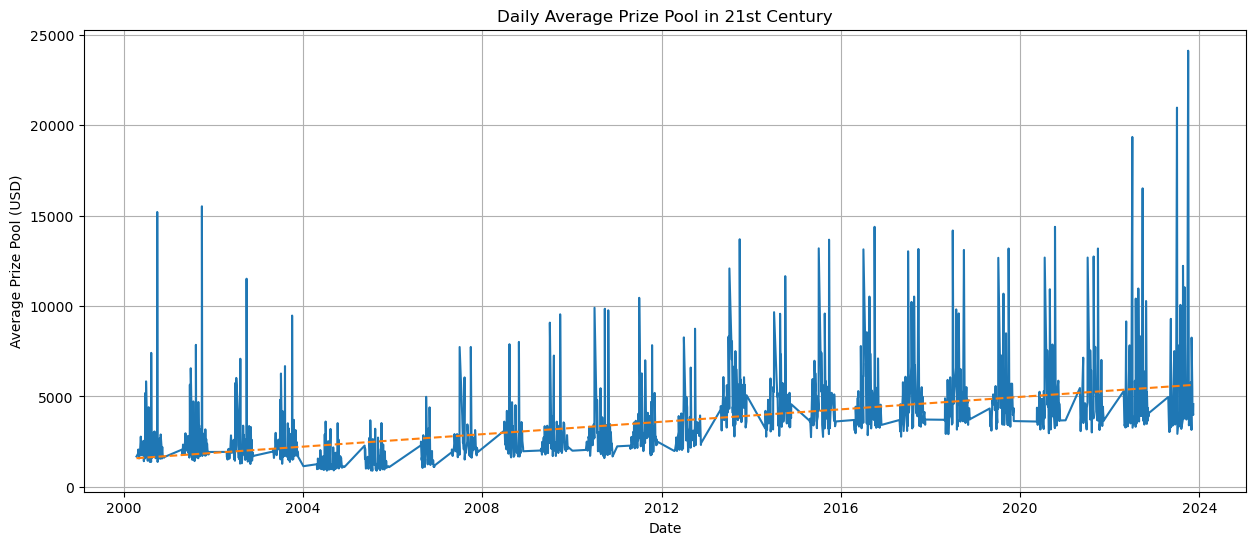

In [25]:
daily_prize = race_data["prize_pool_(USD)"].resample('D').mean()
daily_prize = daily_prize.dropna()

x_axis = daily_prize.index
y_axis = daily_prize.values

fig, ax = plt.subplots()
ax.plot(x_axis, y_axis)

# Add polyfit function for trend line -- After presentation recommendation

x_num = x_axis.map(pd.Timestamp.toordinal)
coef = np.polyfit(x_num, y_axis, 1)
trend = np.poly1d(coef)

# Plot the trendline
ax.plot(x_axis, trend(x_num), linestyle='--')

ax.set(xlabel='Date', ylabel='Average Prize Pool (USD)',
       title='Daily Average Prize Pool in 21st Century')

ax.grid()

fig.set_size_inches(15,6)

plt.show()

## Ipywidget pie chart showing what percentage of races each distance or category makeup.

In [26]:
@interact(race_data_column = ['distance','category'])
def plot_chart(race_data_column):
    counts = race_data[race_data_column].value_counts()
    top_n = 8
    top_counts = counts[:top_n]
    labels = list(top_counts.index)
    values = list(top_counts.values)

    # Sum the rest as 'Other' -- created by ChatGPT so the labels are readable 
    other_count = counts[top_n:].sum()
    num_other_categories = len(counts[top_n:])

    if other_count > 0:
        labels.append(f'Other ({num_other_categories} categories)')
        values.append(other_count)
        
    plt.figure(figsize=(7,7))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(f'Percentage of Races by {race_data_column.capitalize()}')
    plt.show()

interactive(children=(Dropdown(description='race_data_column', options=('distance', 'category'), value='distan…